#

<div align="center">
  
  <img src="https://i.ibb.co/21CrWWPP/Anahuac-Online.png" alt="Anahuac-Online" border="0">

  ### **UNIVERSIDAD ANÁHUAC**
  
  ---
  
  ## **DIPLOMADO EN INTELIGENCIA ARTIFICIAL**
  
  ### **Módulo 1: Python para la inteligencia artificial**
  #### **Unidad 5. Introducción a la econometría con Python**

  <br>
  <br>

  ## **RETO DE APRENDIZAJE:**
  # **Análisis de regresión lineal simple con Python**

  <br>
  <br>
  <br>

  ## **Presenta:**
  ### **José Salvador Aguilar Huerta**

  <br>
  <br>

  ## **Docente / Facilitador:**
  #### **Alejandro Platas López**

  <br>
  <br>
  <br>
  <br>
  <br>

---
  **Puebla, Pue. a 09 de Agosto de 2026**
</div>

<div style="page-break-after: always;"></div>

<h1 style="margin-top:10px; margin-bottom:8px;">
Análisis de regresión lineal simple con Python
</h1>

<hr style="margin-top:12px; margin-bottom:10px;">

<p style="font-size:16px; margin-top:4px; margin-bottom:4px;">
<strong>Objetivo</strong>
</p>
<p style="font-size:14px; text-align:justify; max-width:900px; margin:0 auto 14px auto;">
Aplicar los fundamentos de la estadística para generar, visualizar y analizar tres conjuntos de datos distintos mediante regresión lineal simple en Python, interpretando los resultados obtenidos y su grado de ajuste.
</p>
<p style="font-size:16px; margin-top:4px; margin-bottom:4px;">
<strong>Rubrica</strong>
</p>
<p style="font-size:14px; text-align:justify; max-width:900px; margin:0 auto 14px auto;">

| Criterio | Puntos | Que necesitas |
|----------|--------|---------------|
| Generacion y descripcion de datos | 4 | Tres conjuntos de datos, cada uno con 30-100 observaciones, bien descritos |
| Visualizacion y analisis grafico | 4 | Graficas de dispersion claras, con interpretacion de tendencias |
| Implementacion de regresion lineal | 5 | Codigo funcional con pendiente, intercepto y R² correctos |
| Analisis comparativo | 4 | Comparar los 3 modelos con argumentos estadisticos |
| Conclusiones y reflexion personal | 3 | Reflexion critica conectando teoria con tu practica profesional |

</p>


</div>

**Declaración de Librerías**

In [122]:
# ==========================================
# IMPORTACIÓN DE LIBRERÍAS
# ==========================================
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

print("Librerias importadas correctamente.")

Librerias importadas correctamente.


 **CONJUNTO DE DATOS 1 — RELACION LINEAL FUERTE (NEGATIVA)**
 <br><br>
El Instituto de Energía Natural de Hawái sometio a mas de 1000 ciclos de carga un conjunto de 14 baterías NMC-LCO 18650, en cada ciclo tomó diferentes mediciones acerca de las condiciones de las baterias, entre ellas el indice de vida util restante. A partir de ese conjunto de datos se obtuvo una muestra aleatoria de 100 de esas mediciones, tomando unicamente el **número de ciclo** de la toma y el **indice de vida util restante**. Estos datos por su  naturaleza se espera tengan un comportamiento apegado a una función lineal ideal para este ejercicio, con lo que se esperaría un coeficiente de determinación $R^2$ cercano a $1$.
<br>
Los datos originales estan expuestos en: https://www.kaggle.com/datasets/ignaciovinuales/battery-remaining-useful-life-rul <br>
Y el extracto de datos a utilizar está alojado en: https://raw.githubusercontent.com/aguilarhsalvador/Regresion-lineal-simple-con-Python/refs/heads/main/Vida_Util_Baterias1.csv



**Carga inicial de datos**

In [123]:
# ==============================
# Creación del Dataset 1 Relación Lineal
# ==============================

file_path = "https://raw.githubusercontent.com/aguilarhsalvador/Regresion-lineal-simple-con-Python/refs/heads/main/Vida_Util_Baterias1.csv"

# Cargar el archivo CSV
df1 = pd.read_csv(file_path)

# Mostrar confirmación de carga
print("Dataset cargado correctamente.")
print(f"Número de muestras y variables: {df1.shape}")

# Mostrar información general del dataset
#print("\nInformación general del dataset:")
#df1.info()

# Mostrar tipos de datos
print("\nTipos de datos por variable:")
print(df1.dtypes)

print(f"\nEstadisticas descriptivas:")
display(df1.describe())

print(f"\nGráfico de distribución:")
#Nos aseguramos que el dataset este en orden por el número de ciclo
df1.sort_values(by='Ciclos')

x1=df1['Ciclos'].values
y1=df1['Vida_Util'].values
#print(x1)
#print(y1)


Dataset cargado correctamente.
Número de muestras y variables: (100, 2)

Tipos de datos por variable:
Ciclos         int64
Vida_Util    float64
dtype: object

Estadisticas descriptivas:


,Ciclos,Vida_Util
count,100.000000,100.000000
mean,492.380000,54.670000
std,281.381217,25.059547
min,11.000000,10.000000
25%,259.500000,30.750000
50%,487.000000,56.500000
75%,766.000000,75.250000
max,995.000000,99.000000



Gráfico de distribución:


**Visualización Exploratoria**


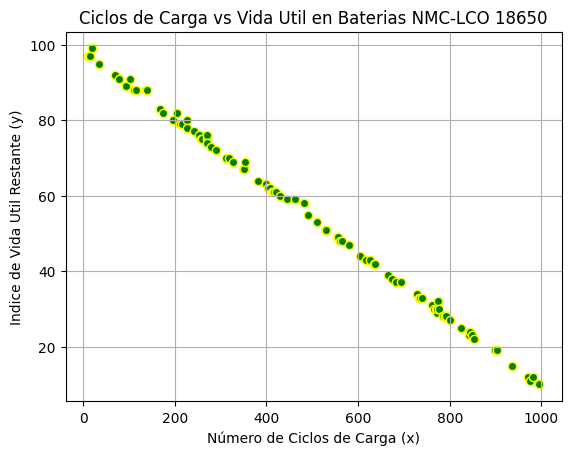

In [124]:
# ==============================
# Graficación
# ==============================

x1=df1[['Ciclos']].values
y1=df1['Vida_Util'].values
plt.scatter(x1, y1, color='green', edgecolor='yellow')
plt.title('Ciclos de Carga vs Vida Util en Baterias NMC-LCO 18650')
plt.xlabel('Número de Ciclos de Carga (x)')
plt.ylabel('Indice de Vida Util Restante (y)')
plt.grid(True)
plt.show()


**OBSERVACIONES**<br>
Se confirma la relación lineal esperada con una tendencia negativa, lo que significa que a mayor número de ciclos de carga la vida util de las baterias tiende a ser menor.<br>
Tambien se observa una dispersion baja con lo que es de esperar un coeficiente de determinación $R^2$ cercano a $1$.

**DIVISIÓN (80/20)**

Entrenamiento: 80 observaciones
Prueba:        20 observaciones

Visualización


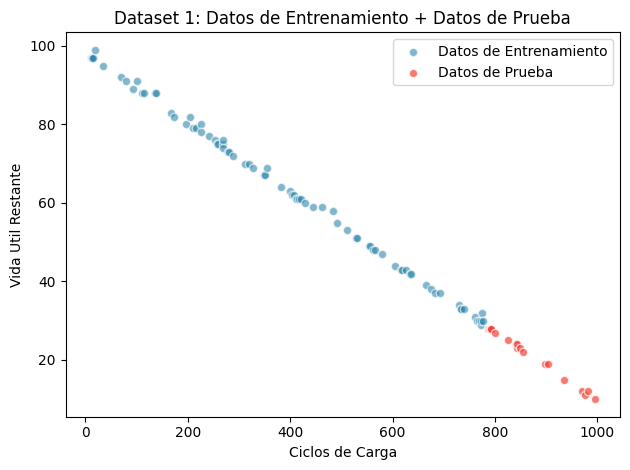

In [125]:
############################################################################
## Creacion de subconjuntos de entrenamiento y prueba en una relación 80/20
############################################################################

#x1_train, x1_test, y1_train, y1_test = train_test_split(x1, y1, test_size=20, random_state=42)

# Aplicaremos una division 80/20 ordenada soble el conjunto de datos sin usar un selector de aleatoriedad
# Esto nos permitirá entrenar nuestro modelo con datos historicos a una fecha y probar el modelo con datos futuros


x1_train = x1[:80]    # Primer 80% (del 0 al 79)
y1_train = y1[:80]    # Primer 80% (del 0 al 79)
x1_test = x1[80:]     # Ultimos 20% (del 80 al 99)
y1_test = y1[80:]     # Ultimos 20% (del 80 al 99)

print(f"Entrenamiento: {len(x1_train)} observaciones")
print(f"Prueba:        {len(x1_test)} observaciones")
print()
print(f"Visualización")

# Grafica: datos de entrenamiento + Datos de Prueba
plt.scatter(x1_train, y1_train, color='#2E86AB', alpha=0.6, label='Datos de Entrenamiento', edgecolors='white')
plt.scatter(x1_test, y1_test, color='#F24236', alpha=0.7, label='Datos de Prueba', edgecolors='white')
plt.xlabel('Ciclos de Carga')
plt.ylabel('Vida Util Restante')
plt.title(f'Dataset 1: Datos de Entrenamiento + Datos de Prueba')
plt.legend()
plt.tight_layout()
plt.show()



**Aplicación del Modelo Lineal Simple**<br>
Aplicaremos el método estadistico de regresión lineal simple y determinaremos las métricas que se utilizan para evaluar el modelo de regresión tales como el coeficiente de determinación ($R^2$), el error absoluto medio ($MAE$), el error cuadratico medio ($MSE$) y la raíz cuadrada del error cuadrático ($RMSE$) <br>
<br>
**Elementos del Modelo**<br>
***Variable Dependiente*** ($Y$): Es el valor que queremos pronosticar o explicar en nuestro ejemplo "La vida util restante de una batería".<br>
***Variable Independiente*** ($X$): Es el factor o predictor que usamos para hacer la estimación en nuestro caso "el número de ciclos de carga efectuados a la batería".<br>
***Línea Recta:*** Se representa con la ecuación ($Y = mX + B$).<br>
***Intercepto:*** El punto donde la recta cruza el eje vertical.<br>
***Pendiente ($m$):*** La inclinación de la recta, que indica cuánto cambia ($Y$) cuando ($X$) aumenta una unidad

In [126]:
modelo1 = LinearRegression()
modelo1.fit(x1_train, y1_train)

y1_pred = modelo1.predict(x1_test)

pendiente1 = modelo1.coef_[0]
intercepto1 = modelo1.intercept_
r2_1 = r2_score(y1_test, y1_pred)
mae_1 = mean_absolute_error(y1_test, y1_pred)
mse_1 = mean_squared_error(y1_test, y1_pred)
rmse_1 = np.sqrt(mean_squared_error(y1_test, y1_pred))

print("=" * 80)
print("Resultados - Dataset 1: Ciclos de Carga vs Vida Util en Baterias NMC-LCO 18650")
print("=" * 80)
print(f"Ecuacion de la recta (y= mx + b): Vida Util = {pendiente1:.4f} * Ciclos de carga + {intercepto1:.4f}")
print(f"Pendiente  :  {pendiente1:.4f}")
print(f"Intercepto :  {intercepto1:.4f}")
print(f"R²:            {r2_1:.4f}")
print(f"MAE:           {mae_1:.4f}")
print(f"MSE:           {mse_1:.4f}")
print(f"RMSE:          {rmse_1:.4f}")
print()


Resultados - Dataset 1: Ciclos de Carga vs Vida Util en Baterias NMC-LCO 18650
Ecuacion de la recta (y= mx + b): Vida Util = -0.0890 * Ciclos de carga + 98.4992
Pendiente  :  -0.0890
Intercepto :  98.4992
R²:            0.9951
MAE:           0.3602
MSE:           0.1941
RMSE:          0.4406



**INTERPRETACION**<br>
El valor de la pendientes es $-0.0890$ lo que significa que por cada ciclo de carga las baterias reducen su vida util en un 0.089 unidades, dado que estamos midiendo la vida util como un porcentage en el rango de 0% a 100%, el resultado se traduce en una disminuciion del $0.089$%.

El modelo presenta un coeficiente de determinación $R^2=0.9951$ lo que se traduce como que el modelo explica 99.51% de la variabilidad en la vida util de las baterias.<br>

El error absoluto medio $MAE$ es de solo $0.3602$ lo que nos dice que en cada predicción que arroje el modelo tenemos una media de error con respecto al valor real de solo 0.3602, valores muy cercanos al dato real.<br>

Por otra parte el $RMSE$ nos indica otra medida de error entre las predicciónes y los datos reales, el propósito de ésta otra medición es ser mas sensible a datos extremos, si el modelo falla por mucho en un solo punto, el valor de RMSE sube notablemente a diferencía del $MAE$ que es mas estable ante datos extremos o valores atípicos. Siempre el $RMSE$ será mayor al $MAE$ y su diferencía nos  indica si hay errores grandes aislados. En nuestro caso la diferencia es ($0.4406 -0.3602 = 0.0804$) lo que denota muy baja o nula presencia de errores atípicos.




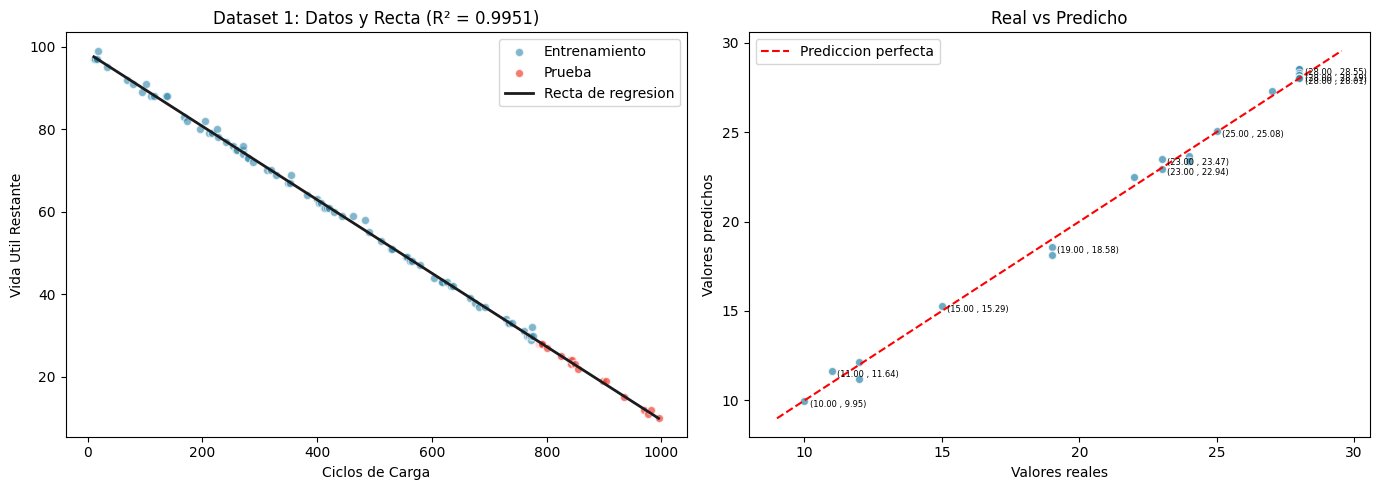

In [127]:

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Grafica izquierda: datos + recta de regresion
axes[0].scatter(x1_train, y1_train, color='#2E86AB', alpha=0.6, label='Entrenamiento', edgecolors='white')
axes[0].scatter(x1_test, y1_test, color='#F24236', alpha=0.7, label='Prueba', edgecolors='white')
x1_linea = np.linspace(x1.min(), x1.max(), 100).reshape(-1, 1)
axes[0].plot(x1_linea, modelo1.predict(x1_linea), color='#1B1B1E', linewidth=2, label='Recta de regresion')
axes[0].set_xlabel('Ciclos de Carga')
axes[0].set_ylabel('Vida Util Restante')
axes[0].set_title(f'Dataset 1: Datos y Recta (R² = {r2_1:.4f})')
axes[0].legend()

# Grafica derecha: valores reales vs predichos
axes[1].scatter(y1_test, y1_pred, color='#2E86AB', alpha=0.7, edgecolors='white')
lim = [min(y1_test.min()-1, y1_pred.min()), max(y1_test.max(), y1_pred.max()+1) ]
axes[1].plot(lim, lim, 'r--', linewidth=1.5, label='Prediccion perfecta')
axes[1].set_xlabel('Valores reales')
axes[1].set_ylabel('Valores predichos')
axes[1].set_title('Real vs Predicho')
axes[1].legend()
band=1
for i, j in zip(y1_test, y1_pred):
    axes[1].text(i+0.2, j - 0.2, f"({i:.2f} , {j:.2f})" if band<0 else "",fontsize=6, ha='left', va='center')
    band*=-1

plt.tight_layout()
plt.show()


**INTERPRETACION**
Las gráficas confirman lo interpretado con los resultados estadisticos, las predicciones que arroja el modelo son altamente apegadas a los los valores reales, la linea recta en la gráfica de la izquierda practicamente toca cada punto de la muestra lo que nos da ese sentido de certeza en el modelo. <br>
Por otra parte la gráfica de la derecha compara los valores predichos contra los reales, una predicción perfecta sería que la linea punteada tocara cada uno de esos punto, lo cual no sucede sin embargo los puntos estan muy cercanos a la linea lo que comprueba un $MAE$ de solo $0.362$ si observamos a detalle cada uno de los valores en cada punto podemos corroborar que la diferencia oscila alrededor de ésta media.<br>
Otro punto observable que que la vida util de éste modelo de baterias es de poco mas de 1000 recargas, si despejaramos X de la ecuacion de la recta podemos calcular su valor para Y=0 lo que resulta en ($98.4992/0.0890=1106.73$), esto es **1,107 ciclos de carga como vida util de las baterias**

_____
_____
 **CONJUNTO DE DATOS 2 — RELACION LINEAL MODERADA**
 <br><br>
El siguiente conjunto de datos corresponde a una extracción del conjunto de datos original "Advertising Dataset" publicado como parte del libro Introduction to Statistical Learning: with Applications de James, G., Witten, D., Hastie, T., & Tibshirani, R. (2013). Los datos expresan el gasto en miles de dolares en publicidad efectuado por una empresa contra el incremento de las ventas en miles de unidades, el dataset incluye 4 columnas etiquetadas como TV, Radio, Newspaper y Sales, las tres primeras son referente al gasto en publicidad y la ultima al incremento en unidades de venta. Para nuestro ejercicio solo estaremos ocupando El gasto en tv (TV) y el incremento en unidades de venta (Sales)
<br>
Los datos originales estan expuestos en: https://www.kaggle.com/datasets/tawfikelmetwally/advertising-dataset <br>
Y el extracto de datos a utilizar está alojado en: https://raw.githubusercontent.com/aguilarhsalvador/Regresion-lineal-simple-con-Python/refs/heads/main/TV_Radio_Newspaper_Sales.cvs



**Carga inicial de datos**

In [128]:
# ==================================================
# Creación del Dataset 2 Relación Lineal Moderada
# ===================================================

file_path = "https://raw.githubusercontent.com/aguilarhsalvador/Regresion-lineal-simple-con-Python/refs/heads/main/TV_Radio_Newspaper_Sales.cvs"

# Cargar el archivo CSV
df2 = pd.read_csv(file_path)

# Mostrar confirmación de carga
print("Dataset cargado correctamente.")
print(f"Número de muestras y variables: {df2.shape}")

# Mostrar información general del dataset
#print("\nInformación general del dataset:")
#df2.info()

# Mostrar tipos de datos
print("\nTipos de datos por variable:")
print(df2.dtypes)

print(f"\nEstadisticas descriptivas:")
display(df2.describe())

print(f"\nGráfico de distribución:")



Dataset cargado correctamente.
Número de muestras y variables: (100, 4)

Tipos de datos por variable:
TV           float64
Radio        float64
Newspaper    float64
Sales        float64
dtype: object

Estadisticas descriptivas:


,TV,Radio,Newspaper,Sales
count,100.000000,100.00000,100.000000,100.000000
mean,148.647000,24.71100,32.350000,14.448000
std,83.776875,14.53639,21.530263,5.128401
min,5.400000,1.40000,0.300000,4.800000
25%,75.150000,12.37500,15.975000,10.600000
50%,145.100000,26.20000,31.550000,13.300000
75%,216.500000,36.87500,45.700000,18.075000
max,293.600000,49.60000,114.000000,25.400000



Gráfico de distribución:


**Visualización Exploratoria**


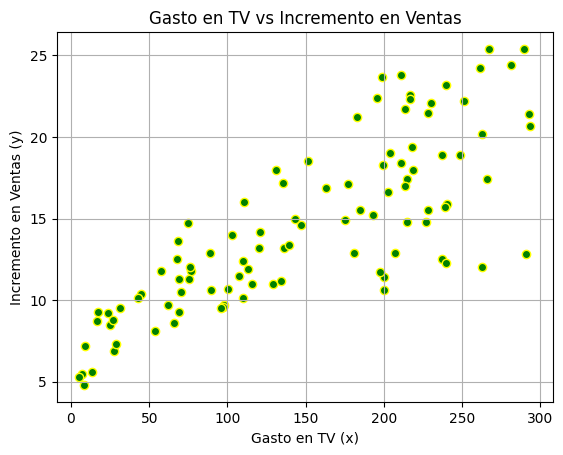

In [129]:
# ==============================
# Graficación
# ==============================

x2=df2[['TV']].values
y2=df2['Sales'].values
plt.scatter(x2, y2, color='green', edgecolor='yellow')
plt.title('Gasto en TV vs Incremento en Ventas')
plt.xlabel('Gasto en TV (x)')
plt.ylabel('Incremento en Ventas (y)')
plt.grid(True)
plt.show()


**OBSERVACIONES**<br>
Se observa una disperción moderada con una tendencia positiva, lo que se traduce que ante mayor gasto en publicidad televisiva exite un mayor incremento en las ventas. <br>
Dada la dispercion observada podemos esperar un coeficiente de determinación $R^2$ cercano al $0.5$.

**DIVISIÓN (80/20)**

Entrenamiento: 80 observaciones
Prueba:        20 observaciones

Visualización


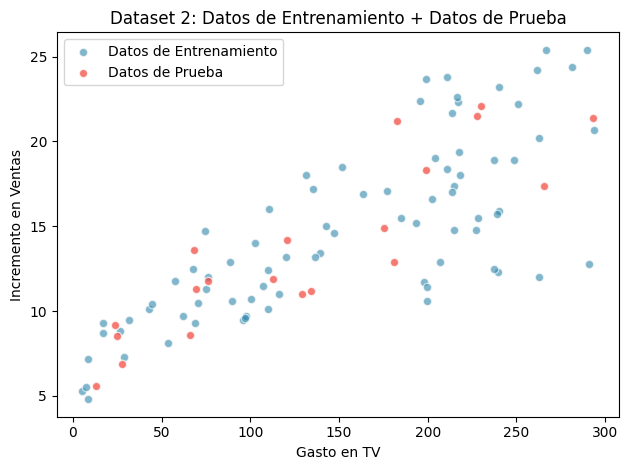

In [130]:
############################################################################
## Creacion de subconjuntos de entrenamiento y prueba en una relación 80/20
############################################################################

x2_train, x2_test, y2_train, y2_test = train_test_split(x2, y2, test_size=20, random_state=42)

print(f"Entrenamiento: {len(x2_train)} observaciones")
print(f"Prueba:        {len(x2_test)} observaciones")
print()
print(f"Visualización")

# Grafica: datos de entrenamiento + Datos de Prueba
plt.scatter(x2_train, y2_train, color='#2E86AB', alpha=0.6, label='Datos de Entrenamiento', edgecolors='white')
plt.scatter(x2_test, y2_test, color='#F24236', alpha=0.7, label='Datos de Prueba', edgecolors='white')
plt.xlabel('Gasto en TV')
plt.ylabel('Incremento en Ventas')
plt.title(f'Dataset 2: Datos de Entrenamiento + Datos de Prueba')
plt.legend()
plt.tight_layout()
plt.show()



**Aplicación del Modelo Lineal Simple**<br>
Aplicaremos el método estadistico de regresión lineal simple y determinaremos las métricas que se utilizan para evaluar el modelo de regresión tales como el coeficiente de determinación ($R^2$), el error absoluto medio ($MAE$), el error cuadratico medio ($MSE$) y la raíz cuadrada del error cuadrático ($RMSE$) <br>
<br>
**Elementos del Modelo**<br>
***Variable Dependiente*** ($Y$): Es el valor que queremos pronosticar o explicar en nuestro ejemplo "Incremento en Ventas".<br>
***Variable Independiente*** ($X$): Es el factor o predictor que usamos para hacer la estimación en nuestro caso "Gasto en publicidad de TV".<br>
***Línea Recta:*** Se representa con la ecuación ($Y = mX + B$).<br>
***Intercepto:*** El punto donde la recta cruza el eje vertical.<br>
***Pendiente ($m$):*** La inclinación de la recta, que indica cuánto cambia ($Y$) cuando ($X$) aumenta una unidad

In [131]:
modelo2 = LinearRegression()
modelo2.fit(x2_train, y2_train)

y2_pred = modelo2.predict(x2_test)

pendiente2 = modelo2.coef_[0]
intercepto2 = modelo2.intercept_
r2_2 = r2_score(y2_test, y2_pred)
mae_2 = mean_absolute_error(y2_test, y2_pred)
mse_2 = mean_squared_error(y2_test, y2_pred)
rmse_2 = np.sqrt(mean_squared_error(y2_test, y2_pred))

print("=" * 80)
print("Resultados - Dataset 2: Gasto en Publicidad de TV vs Incremento en Ventas")
print("=" * 80)
print(f"Ecuacion de la recta (y= mx + b): Incremento de Ventas = {pendiente2:.4f} * Gasto en TV + {intercepto2:.4f}")
print(f"Pendiente  :  {pendiente2:.4f}")
print(f"Intercepto :  {intercepto2:.4f}")
print(f"R²:            {r2_2:.4f}")
print(f"MAE:           {mae_2:.4f}")
print(f"MSE:           {mse_2:.4f}")
print(f"RMSE:          {rmse_2:.4f}")
print()


Resultados - Dataset 2: Gasto en Publicidad de TV vs Incremento en Ventas
Ecuacion de la recta (y= mx + b): Incremento de Ventas = 0.0481 * Gasto en TV + 7.2836
Pendiente  :  0.0481
Intercepto :  7.2836
R²:            0.7827
MAE:           1.9182
MSE:           5.3830
RMSE:          2.3201



**INTERPRETACION**<br>
El valor de la pendientes es $0.0481$ lo que nos indica que por cada unidad de incremento del gasto en publicidad televisa (miles de dolares) se espera un incremento de 0.0481 en miles de unidades vendidas

El modelo presenta un coeficiente de determinación $R^2=0.7827$ lo que se traduce como que el modelo solo da respuesta al 78% de la variabilidad en en el icremento de las ventas,<br>

El error absoluto medio $MAE$ es de $1.9182$ lo que nos dice que en cada predicción que arroje el modelo tenemos una media de error con respecto al valor real de 1.918 unidades.<br>

Por otra parte el $RMSE$ nos indica otra medida de error entre las predicciónes y los datos reales, el propósito de ésta otra medición es ser mas sensible a datos extremos, si el modelo falla por mucho en un solo punto, el valor de RMSE sube notablemente a diferencía del $MAE$ que es mas estable ante datos extremos o valores atípicos. Siempre el $RMSE$ será mayor al $MAE$ y su diferencía nos  indica si hay errores grandes aislados. En nuestro caso la diferencia es ($2.3201 - 1.9182 = 0.4019) lo que denota una moderada presencia de errores atípicos.




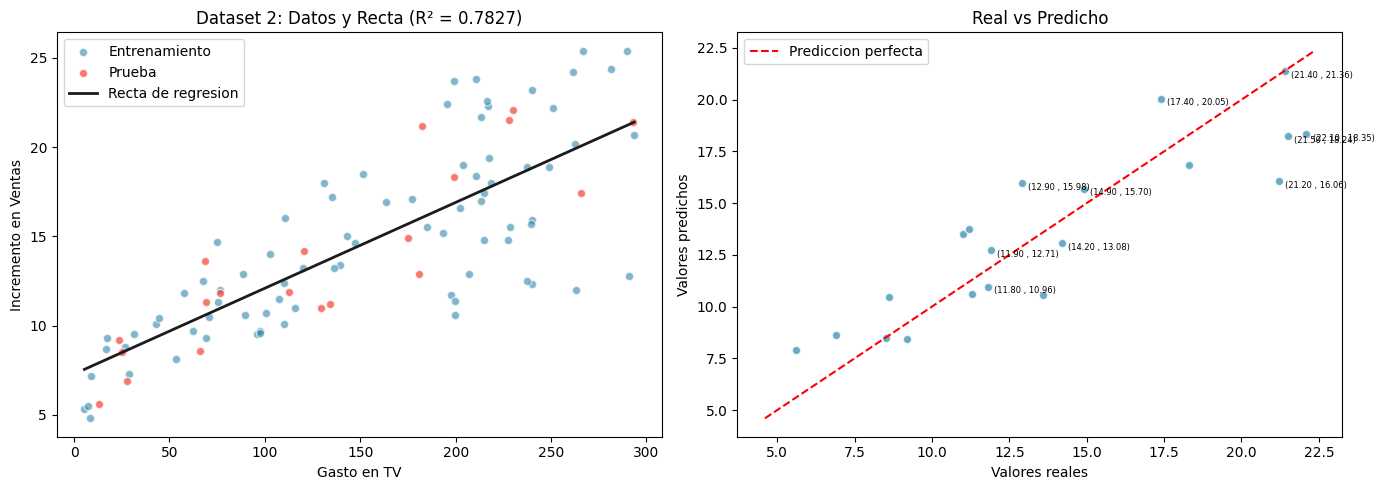

In [132]:

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Grafica izquierda: datos + recta de regresion
axes[0].scatter(x2_train, y2_train, color='#2E86AB', alpha=0.6, label='Entrenamiento', edgecolors='white')
axes[0].scatter(x2_test, y2_test, color='#F24236', alpha=0.7, label='Prueba', edgecolors='white')
x2_linea = np.linspace(x2.min(), x2.max(), 100).reshape(-1, 1)
axes[0].plot(x2_linea, modelo2.predict(x2_linea), color='#1B1B1E', linewidth=2, label='Recta de regresion')
axes[0].set_xlabel('Gasto en TV')
axes[0].set_ylabel('Incremento en Ventas')
axes[0].set_title(f'Dataset 2: Datos y Recta (R² = {r2_2:.4f})')
axes[0].legend()

# Grafica derecha: valores reales vs predichos
axes[1].scatter(y2_test, y2_pred, color='#2E86AB', alpha=0.7, edgecolors='white')
lim = [min(y2_test.min()-1, y2_pred.min()), max(y2_test.max(), y2_pred.max()+1) ]
axes[1].plot(lim, lim, 'r--', linewidth=1.5, label='Prediccion perfecta')
axes[1].set_xlabel('Valores reales')
axes[1].set_ylabel('Valores predichos')
axes[1].set_title('Real vs Predicho')
axes[1].legend()
band=1
for i, j in zip(y2_test, y2_pred):
    axes[1].text(i+0.2, j - 0.2, f"({i:.2f} , {j:.2f})" if band<0 else "",fontsize=6, ha='left', va='center')
    band*=-1

plt.tight_layout()
plt.show()


**INTERPRETACION**
Las gráficas confirman lo interpretado con los resultados estadisticos, las predicciones que arroja el modelo tiene una media de error alrededor de 1.91, la linea recta en la gráfica de la izquierda practicamente parte en dos el conjunto de datos pero tocando muy pocos puntos. <br>
Por otra parte la gráfica de la derecha compara los valores predichos contra los reales, una predicción perfecta sería que la linea punteada tocara cada uno de esos punto sin embargo no es así, los puntos permanecen distamtes a la linea, lo cual comprueba un $MAE$ de $1.91$ si observamos a detalle cada uno de los valores en cada punto podemos corroborar que la diferencia oscila alrededor de ésta media.<br>


_____
_____
 **CONJUNTO DE DATOS 3 — RELACION LINEAL DEBIL O NULA**
 <br><br>
El siguiente conjunto de datos corresponde a una extracción del conjunto de datos original "Diabetes Dataset" publicado kaggle . El conjunto de datos original contiene 100 000 registros sintéticos de pacientes, los datos estan  diseñados para la predicción, el análisis y las aplicaciones de aprendizaje automático del riesgo de diabetes. El conjunto de datos está limpio, preprocesado y listo para su uso en clasificación, regresión, ingeniería de características, análisis estadístico y visualización de datos. Para nuestro ejercicio solo estaremos ocupando un subconjunto de 100 registros y nos enfocaremos en las variables "diabetes_risk_score" y "sleep_hours_per_day" que nos indica el riesgo de diabetes  y las horas de sueño de cada individuo en el ensayo.
<br>
Los datos originales estan expuestos en: https://www.kaggle.com/datasets/mohankrishnathalla/diabetes-health-indicators-dataset <br>
Y el extracto de datos a utilizar está alojado en: https://raw.githubusercontent.com/aguilarhsalvador/Regresion-lineal-simple-con-Python/refs/heads/main/diabetes_dataset.cvs



**Carga inicial de datos**

In [133]:
# ==================================================
# Creación del Dataset 3 Relación Lineal debil o nula
# ===================================================

file_path = "https://raw.githubusercontent.com/aguilarhsalvador/Regresion-lineal-simple-con-Python/refs/heads/main/diabetes_dataset.csv"

# Cargar el archivo CSV y Obtenemos solo los 100 primeros registros
df3 = pd.read_csv(file_path)
df3=df3.head(100)

# Mostrar confirmación de carga
print("Dataset cargado correctamente.")
print(f"Número de muestras y variables: {df3.shape}")

# Mostrar información general del dataset
#print("\nInformación general del dataset:")
#df3.info()

# Mostrar tipos de datos
print("\nTipos de datos por variable:")
print(df3.dtypes)

print(f"\nEstadisticas descriptivas:")
display(df3.describe())

print(f"\nGráfico de distribución:")



Dataset cargado correctamente.
Número de muestras y variables: (100, 31)

Tipos de datos por variable:
age                                     int64
gender                                 object
ethnicity                              object
education_level                        object
income_level                           object
employment_status                      object
smoking_status                         object
alcohol_consumption_per_week            int64
physical_activity_minutes_per_week      int64
diet_score                            float64
sleep_hours_per_day                   float64
screen_time_hours_per_day             float64
family_history_diabetes                 int64
hypertension_history                    int64
cardiovascular_history                  int64
bmi                                   float64
waist_to_hip_ratio                    float64
systolic_bp                             int64
diastolic_bp                            int64
heart_rate             

,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,family_history_diabetes,hypertension_history,cardiovascular_history,bmi,...,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diagnosed_diabetes
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.00000,100.000000,100.000000,100.000000,...,100.000000,100.000000,100.00000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,48.400000,1.770000,104.060000,6.273000,6.959000,6.330000,0.21000,0.260000,0.070000,25.352000,...,189.480000,54.970000,103.81000,119.360000,111.580000,162.790000,8.665900,6.642200,29.775000,0.650000
std,14.303351,1.406012,62.925773,1.893949,1.169831,2.439883,0.40936,0.440844,0.256432,3.723458,...,34.252326,9.104838,35.75582,45.048912,14.187902,31.597307,4.770485,0.839015,9.026217,0.479372
min,18.000000,0.000000,13.000000,0.800000,4.500000,0.500000,0.00000,0.000000,0.000000,18.000000,...,116.000000,33.000000,50.00000,30.000000,76.000000,85.000000,2.000000,4.780000,7.300000,0.000000
25%,40.000000,1.000000,59.000000,5.375000,6.100000,5.100000,0.00000,0.000000,0.000000,22.700000,...,162.000000,48.000000,74.00000,85.000000,101.000000,143.000000,4.852500,6.045000,23.450000,0.000000
50%,48.000000,1.500000,89.500000,6.450000,7.050000,6.250000,0.00000,0.000000,0.000000,24.900000,...,188.500000,55.000000,99.50000,119.000000,111.000000,166.500000,8.275000,6.670000,27.850000,1.000000
75%,56.500000,3.000000,135.000000,7.425000,7.625000,8.125000,0.00000,1.000000,0.000000,28.125000,...,216.500000,61.250000,128.75000,147.250000,120.250000,181.500000,12.385000,7.172500,35.225000,1.000000
max,80.000000,6.000000,364.000000,10.000000,10.000000,12.900000,1.00000,1.000000,1.000000,33.600000,...,278.000000,75.000000,195.00000,223.000000,154.000000,253.000000,22.040000,9.030000,51.900000,1.000000



Gráfico de distribución:


**Visualización Exploratoria**


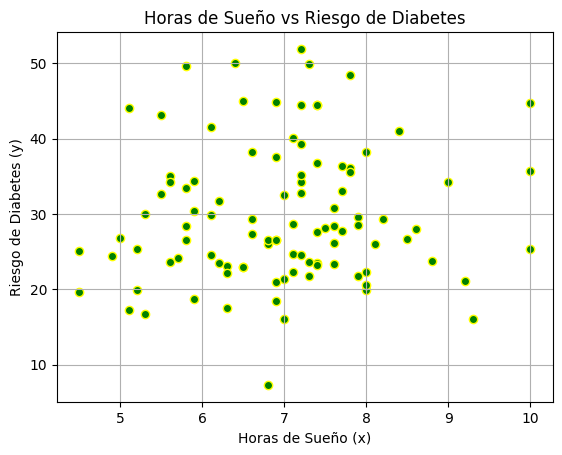

In [134]:
# ==============================
# Graficación
# ==============================

x3=df3[['sleep_hours_per_day']].values
y3=df3['diabetes_risk_score'].values
plt.scatter(x3, y3, color='green', edgecolor='yellow')
plt.title('Horas de Sueño vs Riesgo de Diabetes')
plt.xlabel('Horas de Sueño (x)')
plt.ylabel('Riesgo de Diabetes (y)')
plt.grid(True)
plt.show()


**OBSERVACIONES**<br>
Se observa una disperción baja sin una tendencia marcada, lo que se traduce que no existe una relación definida entre las horas de sueño y el riesgo de padecer diabetes. <br>
Dada la dispercion observada podemos esperar un coeficiente de determinación $R^2$ por abajo del $0.5$.

**DIVISIÓN (80/20)**

Entrenamiento: 80 observaciones
Prueba:        20 observaciones

Visualización


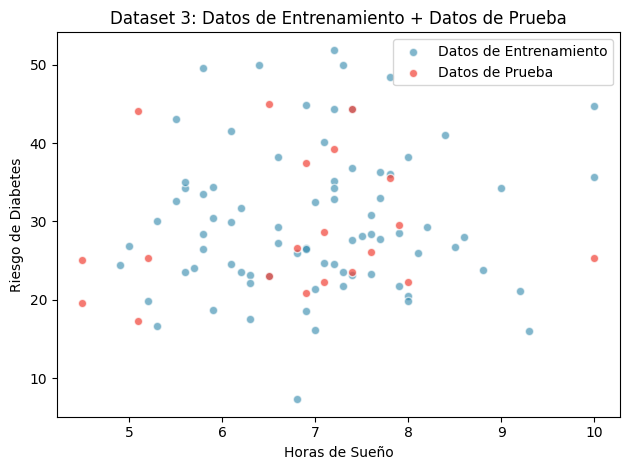

In [135]:
############################################################################
## Creacion de subconjuntos de entrenamiento y prueba en una relación 80/20
############################################################################

x3_train, x3_test, y3_train, y3_test = train_test_split(x3, y3, test_size=20, random_state=42)

print(f"Entrenamiento: {len(x3_train)} observaciones")
print(f"Prueba:        {len(x3_test)} observaciones")
print()
print(f"Visualización")

# Grafica: datos de entrenamiento + Datos de Prueba
plt.scatter(x3_train, y3_train, color='#2E86AB', alpha=0.6, label='Datos de Entrenamiento', edgecolors='white')
plt.scatter(x3_test, y3_test, color='#F24236', alpha=0.7, label='Datos de Prueba', edgecolors='white')
plt.xlabel('Horas de Sueño')
plt.ylabel('Riesgo de Diabetes')
plt.title(f'Dataset 3: Datos de Entrenamiento + Datos de Prueba')
plt.legend()
plt.tight_layout()
plt.show()



**Aplicación del Modelo Lineal Simple**<br>
Aplicaremos el método estadistico de regresión lineal simple y determinaremos las métricas que se utilizan para evaluar el modelo de regresión tales como el coeficiente de determinación ($R^2$), el error absoluto medio ($MAE$), el error cuadratico medio ($MSE$) y la raíz cuadrada del error cuadrático ($RMSE$) <br>
<br>
**Elementos del Modelo**<br>
***Variable Dependiente*** ($Y$): Es el valor que queremos pronosticar o explicar en nuestro ejemplo "Riesgo de Diabetes".<br>
***Variable Independiente*** ($X$): Es el factor o predictor que usamos para hacer la estimación en nuestro caso "Horas de Sueño".<br>
***Línea Recta:*** Se representa con la ecuación ($Y = mX + B$).<br>
***Intercepto:*** El punto donde la recta cruza el eje vertical.<br>
***Pendiente ($m$):*** La inclinación de la recta, que indica cuánto cambia ($Y$) cuando ($X$) aumenta una unidad

In [136]:
modelo3 = LinearRegression()
modelo3.fit(x3_train, y3_train)

y3_pred = modelo3.predict(x3_test)

pendiente3 = modelo3.coef_[0]
intercepto3 = modelo3.intercept_
r2_3 = r2_score(y3_test, y3_pred)
mae_3 = mean_absolute_error(y3_test, y3_pred)
mse_3 = mean_squared_error(y3_test, y3_pred)
rmse_3 = np.sqrt(mean_squared_error(y3_test, y3_pred))

print("=" * 80)
print("Resultados - Dataset 3: Horas de Sueño vs Riesgo de Diabetes")
print("=" * 80)
print(f"Ecuacion de la recta (y= mx + b): Riesgo de Diabetes = {pendiente3:.4f} * Horas de Sueño + {intercepto3:.4f}")
print(f"Pendiente  :  {pendiente3:.4f}")
print(f"Intercepto :  {intercepto3:.4f}")
print(f"R²:            {r2_3:.4f}")
print(f"MAE:           {mae_3:.4f}")
print(f"MSE:           {mse_3:.4f}")
print(f"RMSE:          {rmse_3:.4f}")
print()


Resultados - Dataset 3: Horas de Sueño vs Riesgo de Diabetes
Ecuacion de la recta (y= mx + b): Riesgo de Diabetes = 0.6066 * Horas de Sueño + 25.7022
Pendiente  :  0.6066
Intercepto :  25.7022
R²:            0.0010
MAE:           7.4295
MSE:           72.2842
RMSE:          8.5020



**INTERPRETACION**<br>
El modelo presenta un coeficiente de determinación $R^2=0.0010$ muy cercano a cero lo que nos confirma que no existe una relación entre las horas de sueño y el riesgo de padecer diabetes.<br>

El modelo no aporta mayor valor frente a usar simplemente la media aritmética de los datos como pronóstico.




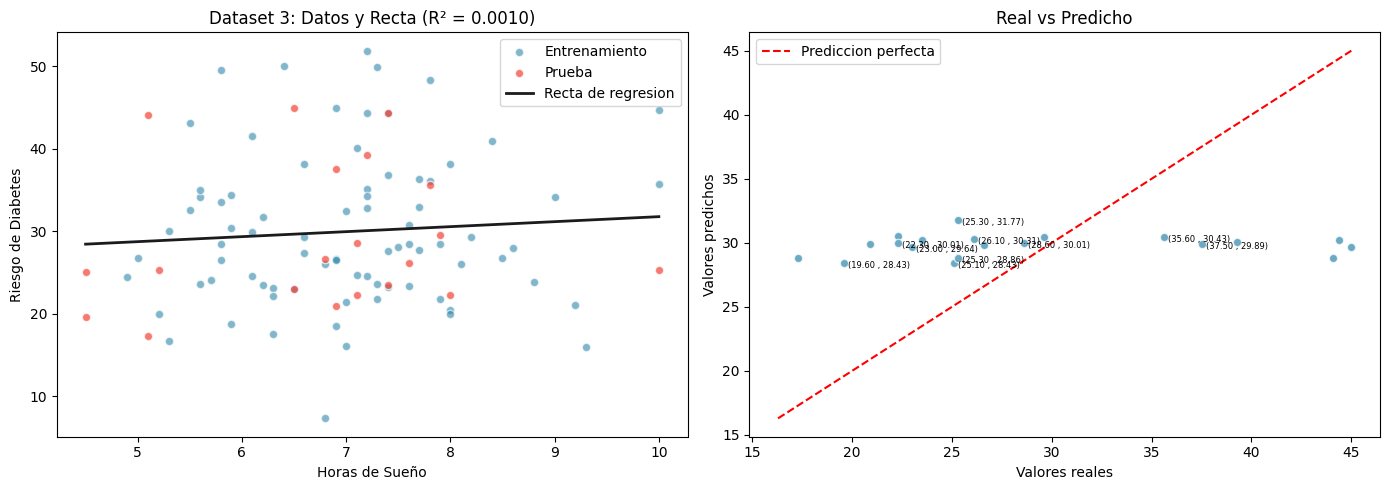

In [137]:

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Grafica izquierda: datos + recta de regresion
axes[0].scatter(x3_train, y3_train, color='#2E86AB', alpha=0.6, label='Entrenamiento', edgecolors='white')
axes[0].scatter(x3_test, y3_test, color='#F24236', alpha=0.7, label='Prueba', edgecolors='white')
x3_linea = np.linspace(x3.min(), x3.max(), 100).reshape(-1, 1)
axes[0].plot(x3_linea, modelo3.predict(x3_linea), color='#1B1B1E', linewidth=2, label='Recta de regresion')
axes[0].set_xlabel('Horas de Sueño')
axes[0].set_ylabel('Riesgo de Diabetes')
axes[0].set_title(f'Dataset 3: Datos y Recta (R² = {r2_3:.4f})')
axes[0].legend()

# Grafica derecha: valores reales vs predichos
axes[1].scatter(y3_test, y3_pred, color='#2E86AB', alpha=0.7, edgecolors='white')
lim = [min(y3_test.min()-1, y3_pred.min()), max(y3_test.max(), y3_pred.max()+1) ]
axes[1].plot(lim, lim, 'r--', linewidth=1.5, label='Prediccion perfecta')
axes[1].set_xlabel('Valores reales')
axes[1].set_ylabel('Valores predichos')
axes[1].set_title('Real vs Predicho')
axes[1].legend()
band=1
for i, j in zip(y3_test, y3_pred):
    axes[1].text(i+0.2, j - 0.2, f"({i:.2f} , {j:.2f})" if band>0 else "",fontsize=6, ha='left', va='center')
    band*=-1

plt.tight_layout()
plt.show()


**INTERPRETACION**
Las gráficas confirman lo interpretado con los resultados estadisticos, la recta mostrada por el modelo de regresion lineal es practicamente horizontal lo que confirma el valor $R^2$ cercano a cero. <br>
Por otra parte la gráfica de la derecha compara los valores predichos contra los reales, los puntos permanecen muy distantes de la linea recta lo que confirma que el modelo no aporta mayores datos.<br>


-----
-----

**TABLA COMPARATIVA DE METRICAS**


In [138]:
resultados = pd.DataFrame({
    'Dataset': ['1. Ciclos de Carga vs Vida Util de las Baterías',
                '2. Gasto en TV vs Incremento de las Ventas',
                '3. Horas de Sueño vs Riesgo de Diabetes'],
    'n': [len(x1), len(x2), len(x3)],
    'Pendiente': [round(pendiente1, 4), round(pendiente2, 4), round(pendiente3, 4)],
    'Intercepto': [round(intercepto1, 4), round(intercepto2, 4), round(intercepto3, 4)],
    'R²': [round(r2_1, 4), round(r2_2, 4), round(r2_3, 4)],
    'MAE': [round(mae_1, 4), round(mae_2, 4), round(mae_3, 4)],
    'RMSE': [round(rmse_1, 4), round(rmse_2, 4), round(rmse_3, 4)]
}).set_index('Dataset')

print("TABLA COMPARATIVA DE METRICAS")
print("=" * 65)
resultados

TABLA COMPARATIVA DE METRICAS


,n,Pendiente,Intercepto,R²,MAE,RMSE
Dataset,,,,,,
1. Ciclos de Carga vs Vida Util de las Baterías,100,-0.0890,98.4992,0.9951,0.3602,0.4406
2. Gasto en TV vs Incremento de las Ventas,100,0.0481,7.2836,0.7827,1.9182,2.3201
3. Horas de Sueño vs Riesgo de Diabetes,100,0.6066,25.7022,0.0010,7.4295,8.5020


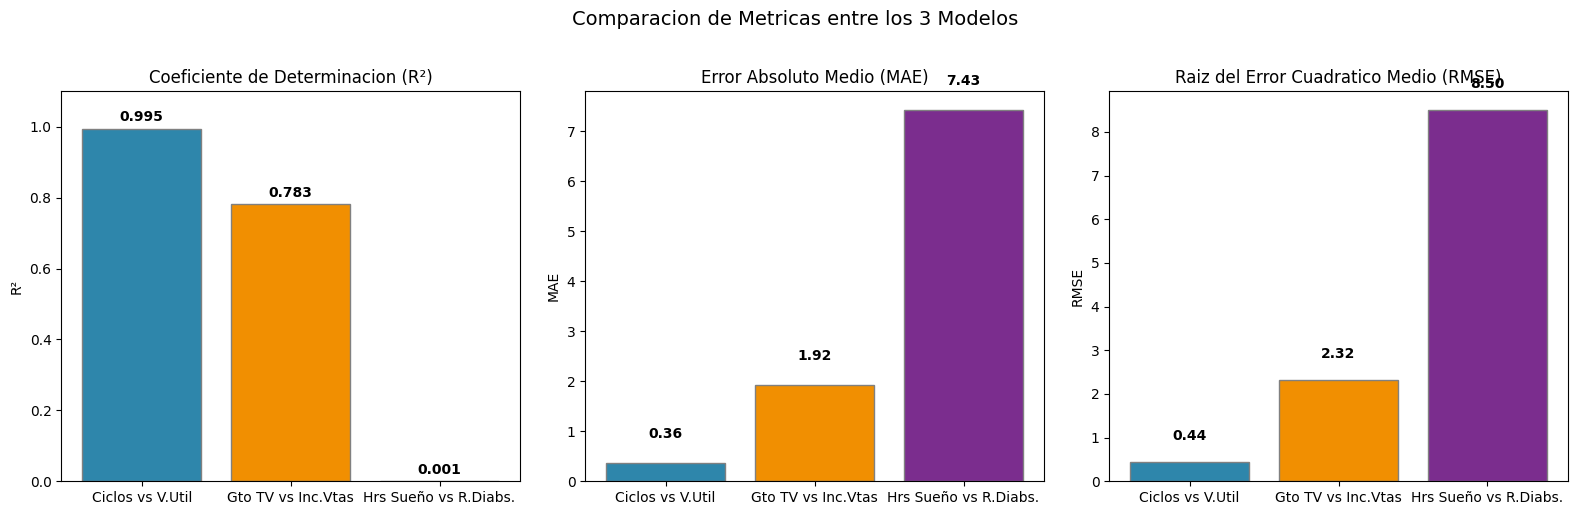

In [139]:

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colores = ['#2E86AB', '#F18F01', '#7B2D8E']
nombres = ['Ciclos vs V.Util', 'Gto TV vs Inc.Vtas', 'Hrs Sueño vs R.Diabs.']

# R²
vals_r2 = [r2_1, r2_2, r2_3]
barras = axes[0].bar(nombres, vals_r2, color=colores, edgecolor='gray')
axes[0].set_ylabel('R²')
axes[0].set_title('Coeficiente de Determinacion (R²)')
axes[0].set_ylim(0, 1.1)
for b, v in zip(barras, vals_r2):
    axes[0].text(b.get_x() + b.get_width()/2, b.get_height() + 0.02,
                 f'{v:.3f}', ha='center', fontweight='bold', fontsize=10)

# MAE
vals_mae = [mae_1, mae_2, mae_3]
barras = axes[1].bar(nombres, vals_mae, color=colores, edgecolor='gray')
axes[1].set_ylabel('MAE')
axes[1].set_title('Error Absoluto Medio (MAE)')
for b, v in zip(barras, vals_mae):
    axes[1].text(b.get_x() + b.get_width()/2, b.get_height() + 0.5,
                 f'{v:.2f}', ha='center', fontweight='bold', fontsize=10)

# RMSE
vals_rmse = [rmse_1, rmse_2, rmse_3]
barras = axes[2].bar(nombres, vals_rmse, color=colores, edgecolor='gray')
axes[2].set_ylabel('RMSE')
axes[2].set_title('Raiz del Error Cuadratico Medio (RMSE)')
for b, v in zip(barras, vals_rmse):
    axes[2].text(b.get_x() + b.get_width()/2, b.get_height() + 0.5,
                 f'{v:.2f}', ha='center', fontweight='bold', fontsize=10)

plt.suptitle('Comparacion de Metricas entre los 3 Modelos', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
---
**Analisis comparativo**

Sin duda los mejores resultados se obtuvieron en el **conjunto de datos 1** donde analizamos la relación entre el número de ciclos de carga a los que se someten las baterías y su vida útil. En éste escenario se obtuvo un $R^2$ muy cercano al 1 y donde se puede concluir de mejor manera las predicciones con un error muy bajo. La aplicación del modelo de regresión lineal es totalmente un éxito en este tipo de conjuntos de datos con un alta relación entre sus variables, podemos tener alta confianza en sus predicción y los valores de error medio serán muy bajos o depreciables.
<br>
En el **conjunto de datos 2** comparamos el gasto en publicidad televisiva contra el incremento en las ventas, en éste caso la relación es moderada obteniendo un coeficiente de determinación $R^2=0.783$, lo que lo sitúa mas alejado del 1, podríamos incluso señalar que solo 78% de los valores pueden ser definidos por la recta de la regresión lineal, El error absoluto medio $MAE$ y la raíz cuadrada del error cuadrático medio $RMSE$ son valores mayores 1.92 y 2.32 respectivamente lo que reduce la eficiencia de las predicciones, sin embargo el modelo continua siendo de gran ayuda y puede servir de apertura a la utilización de otros modelos mas robustos. El propio conjunto de datos contiene otra dos variables que son el gasto en publicidad radiofónica y el gasto en publicidad en periódicos, si ampliáramos el modelo a tomar en consideración estos datos podemos concluir en datos mas precisos. O bien si el valor del error resulta comprensible y aceptable en el mundo real podemos concluir en resultados aceptables.
<br>
En el **tercer conjunto** comparamos el número de horas de sueño contra el riesgo de padecer diabetes, el resultado de $R^2=0.001$ concluye que el número de horas de sueño no tiene relación con el riesgo de padecer diabetes, pueden existir otros factores como una condición herediraria y otros pero no las horas de sueño, podriamos concluir que la regresion lineal no aporta informacion util para este par de variables sin embargo el solo echo de arrojarnos un valor muy cercano a cero ya nos permite concluir un punto importante en el riesgo de padecimiento de la diabetes descartando el análisis de las horas de sueño de los pacientes.



-----
-----
**CONCLUSIONES Y REFLEXIONES**

La regresión lineal simple representa un punto fundamental del modelado predictivo y del análisis estadistico. Su formulación matemática sencilla y bajo costo de procesamiento resulta ideal para un punto de partida obteniendo conclusiones que nos permita dirigir posteriores pasos de ánalisis, su verdadero valor no radica en su capacidad para resolver cualquier problema de datos, sino en su función como **Punto inicial de exploración y diagnostico**.

Conociendo sus limitaciones y alcances, y con un conocimiento del contexto donde estamos aplicandolo podemos llegar a conclusiones muy valiosas que quizas con un modelo matemáticamente perfecto pero sin conocimiento del contexto y con variables irrelevantes no podriamos, un modelo simple construido sobre hipótesis sólidas y evaluado adecuadamente es una **herramienta estratégica de alto valor**.

El coeficiente de determinación ($R^2$) suele malinterpretarse como el único indicador de éxito. Sin embargo, en el análisis práctico de fenómenos reales un valor de $R^2$ igual o muy cercano a $0.00$ puede llevarnos a **conclusiones valiosas**. El Confirmar una independencia entre las variables puede evitar sobre análisis y decisiones erroneas.

Para garantizar la validez de un análisis, la metodología nos exige la elección de variables predictoras que deben obedecer al contexto del fenomeno a evaluar, una mala elección de variables arruina la capacidad explicativa del modelo.

Otro Punto importante es la evaluación del desempeño del modelo partiendo el conjunto de datos reales en datos de entrenamiento y datos de pueba esto nos conduce a obtener mayor acertividad en las predicciones.

**Caso de uso concreto:** Puede utilizarse para evaluar la relación entre el tiempo de entrega de parte de los proveedores (*lead time*) y el volumen de ordenes de compra y con ello modificar las fechas estimadas de llegada de mercancias.
